# 🏡 Bangalore Real Estate Price Prediction & Market Analysis
**An End-to-End Machine Learning and Econometric Valuation Study**

---

### 📌 1. Project Overview & Business Problem
Bangalore (Bengaluru), often hailed as the "Silicon Valley of India," is one of the fastest-growing metropolitan economies in Asia. With millions of tech professionals migrating to the city, the real estate market is characterized by extreme price variance driven by:
- **Location Premiums**: Tech corridors (Whitefield, Electronic City, Bellandur) vs. central heritage zones (Indiranagar, Koramangala, Rajaji Nagar).
- **Property Configurations**: Total square footage, number of bedrooms (BHK), bathroom-to-room ratios, and area construction types (Super built-up vs. Plot vs. Carpet area).
- **Market Asymmetries & Outliers**: Speculative pricing, extreme outliers, and non-standard data entries (e.g., fractional square yard inputs, price spikes).

#### 🎯 Primary Project Objectives:
1. **Data Preprocessing & Cleaning**: Standardize non-numeric square footage ranges, handle missing values, and extract clean numerical features (`bhk`, `total_sqft`, `price_per_sqft`).
2. **Domain-Driven Outlier Removal**: Implement rigorous statistical and real estate domain filters to eliminate anomalies (unrealistic square footage per bedroom, abnormal bathroom counts, and location-wise price per sqft spikes).
3. **Exploratory Data Analysis (EDA)**: Uncover spatial and structural pricing patterns across major Bangalore localities.
4. **Machine Learning Benchmarking**: Train and optimize candidate regression models (**Linear Regression**, **Lasso**, **Ridge**, **Decision Tree**, **Random Forest**, and **Gradient Boosting**) using **5-Fold Cross-Validation**.
5. **Real-Time Property Valuation Function**: Provide an interactive `predict_price(location, sqft, bath, bhk)` interface for instantaneous property appraisals in Lakhs (INR).

## ⚙️ 2. Environment Setup & Data Ingestion
We import core scientific computing, visualization, and machine learning libraries, loading the dataset using relative filepaths.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visual styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 110

# Load dataset
df_raw = pd.read_csv('bengaluru_house_prices.csv')
print(f"Dataset Loaded Successfully: {df_raw.shape[0]:,} properties × {df_raw.shape[1]} columns.")
df_raw.head()

Dataset Loaded Successfully: 13,320 properties × 9 columns.


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


## 🔍 3. Initial Data Profiling & Dimensionality Assessment
Let's examine column data types, missing value distributions, and categorical feature frequencies.

In [2]:
# Summary information and missing values
print("--- DataFrame Info ---")
df_raw.info()

print("\n--- Null Value Count by Column ---")
nulls = df_raw.isnull().sum()
print(nulls[nulls > 0])

--- DataFrame Info ---
<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), str(6)
memory usage: 1.6 MB

--- Null Value Count by Column ---
location       1
size          16
society     5502
bath          73
balcony      609
dtype: int64


### 🛠️ Feature Pruning & Missing Value Treatment
- **`society`**: Contains **5,502 missing values** (over 41% of data) with over 2,600 unique categorical levels. Since society names have excessive granularity and high missingness, we drop this column.
- **`availability`**: Mostly categorizes future possession dates vs. 'Ready To Move' without consistent linear relationship to underlying asset price. We drop this column for valuation modeling.
- **`size` & `location`**: Critical property identifiers with very few nulls ($<0.1\%$). We drop records with missing values in these core columns.

In [3]:
# Drop non-essential / sparse columns
df = df_raw.drop(columns=['society', 'availability']).copy()

# Drop rows missing core location or size attributes
df = df.dropna(subset=['location', 'size'])
print(f"Shape after initial pruning: {df.shape[0]:,} rows × {df.shape[1]} columns")

Shape after initial pruning: 13,303 rows × 7 columns


## 📐 4. Feature Engineering: BHK & Square Footage Standardization

### 1. Extracting Bedroom Count (`bhk`)
The `size` column contains strings such as `'2 BHK'`, `'4 Bedroom'`, `'3 BHK'`. We parse the leading integer to construct an integer `bhk` feature.

In [4]:
# Extract BHK integer
df['bhk'] = df['size'].apply(lambda x: int(x.split(' ')[0]))
df[['size', 'bhk']].head()

,size,bhk
0,2 BHK,2
1,4 Bedroom,4
2,3 BHK,3
3,3 BHK,3
4,2 BHK,2


### 2. Standardizing `total_sqft`
The `total_sqft` column contains a mix of single numbers, ranges (e.g., `'2100 - 2850'`), and non-standard unit strings (e.g., `'34.46Sq. Meter'`). We write a parser to take the average of numerical ranges and convert valid strings to floats.

In [5]:
def convert_sqft_to_num(x):
    tokens = str(x).split('-')
    if len(tokens) == 2:
        return (float(tokens[0]) + float(tokens[1])) / 2
    try:
        return float(x)
    except:
        return None

df['total_sqft'] = df['total_sqft'].apply(convert_sqft_to_num)
df = df.dropna(subset=['total_sqft', 'bath'])
print(f"Shape after square footage conversion: {df.shape[0]:,} rows")
df[['total_sqft', 'bhk', 'bath', 'price']].head()

Shape after square footage conversion: 13,200 rows


,total_sqft,bhk,bath,price
0,1056.0,2,2.0,39.07
1,2600.0,4,5.0,120.00
2,1440.0,3,2.0,62.00
3,1521.0,3,3.0,95.00
4,1200.0,2,2.0,51.00


### 3. Calculating Price per Square Foot (`price_per_sqft`)
Because property price is given in **Lakhs (INR)** ($1\text{ Lakh} = 100,000\text{ INR}$), we calculate the normalized unit price:
$$\text{Price per Sqft} = \frac{\text{Price} \times 100,000}{\text{total\_sqft}}$$

In [6]:
df['price_per_sqft'] = (df['price'] * 100000) / df['total_sqft']
df[['location', 'total_sqft', 'bhk', 'price', 'price_per_sqft']].head()

,location,total_sqft,bhk,price,price_per_sqft
0,Electronic City Phase II,1056.0,2,39.07,3699.810606
1,Chikka Tirupathi,2600.0,4,120.00,4615.384615
2,Uttarahalli,1440.0,3,62.00,4305.555556
3,Lingadheeranahalli,1521.0,3,95.00,6245.890861
4,Kothanur,1200.0,2,51.00,4250.000000


### 4. Dimensionality Reduction for `location`
With over **1,300 unique locations**, one-hot encoding directly would create high dimensional sparsity. We clean whitespace and aggregate any location with **$\le 10$ properties** into an `'other'` category.

In [7]:
# Clean whitespace
df['location'] = df['location'].apply(lambda x: x.strip())

# Identify frequency
location_stats = df['location'].value_counts()
location_stats_less_than_10 = location_stats[location_stats <= 10]

df['location'] = df['location'].apply(lambda x: 'other' if x in location_stats_less_than_10 else x)
print(f"Unique location clusters: {df['location'].nunique()} (reduced from {len(location_stats):,})")

Unique location clusters: 241 (reduced from 1,287)


## 🛡️ 5. Domain-Driven & Statistical Outlier Removal

In real estate data, anomalies, typos, and extreme outliers distort linear and tree models. We implement four domain filters:

1. **Square Footage per Bedroom Outlier Filter**: A standard residential bedroom requires at least **300 sq ft** of total living area. Properties with $\text{total\_sqft} / \text{bhk} < 300$ are invalid entries (e.g., 6 BHK in 1000 sq ft).
2. **Location-Specific Price per Sqft Outlier Filter**: Within each locality, we filter out prices beyond **$\mu \pm 1\sigma$** to remove extreme speculative spikes and data entry errors.
3. **BHK Price Inversion Filter**: In the same locality, a 2 BHK should not cost more than a 3 BHK of identical square footage.
4. **Bathroom Count Anomaly Filter**: Properties where $\text{bath} > \text{bhk} + 2$ are anomalous.

In [8]:
# 1. Filter: Total Sqft per BHK >= 300
initial_len = len(df)
df = df[~(df['total_sqft'] / df['bhk'] < 300)]
print(f"Removed {initial_len - len(df)} rows where sqft per BHK < 300 sqft.")

Removed 744 rows where sqft per BHK < 300 sqft.


In [9]:
# 2. Filter: Location-wise Price per Sqft (mean +/- 1 std)
def remove_pps_outliers(df_in):
    df_out = pd.DataFrame()
    for key, subdf in df_in.groupby('location'):
        m = np.mean(subdf.price_per_sqft)
        st = np.std(subdf.price_per_sqft)
        reduced_df = subdf[(subdf.price_per_sqft > (m - st)) & (subdf.price_per_sqft <= (m + st))]
        df_out = pd.concat([df_out, reduced_df], ignore_index=True)
    return df_out

len_before = len(df)
df = remove_pps_outliers(df)
print(f"Removed {len_before - len(df)} price per sqft statistical outliers.")

Removed 2214 price per sqft statistical outliers.


In [10]:
# 3. Filter: Remove BHK Pricing Inversions within same location
def remove_bhk_outliers(df_in):
    exclude_indices = np.array([])
    for location, location_df in df_in.groupby('location'):
        bhk_stats = {}
        for bhk, bhk_df in location_df.groupby('bhk'):
            bhk_stats[bhk] = {
                'mean': np.mean(bhk_df.price_per_sqft),
                'std': np.std(bhk_df.price_per_sqft),
                'count': bhk_df.shape[0]
            }
        for bhk, bhk_df in location_df.groupby('bhk'):
            stats = bhk_stats.get(bhk - 1)
            if stats and stats['count'] > 5:
                exclude_indices = np.append(exclude_indices, bhk_df[bhk_df.price_per_sqft < (stats['mean'])].index.values)
    return df_in.drop(exclude_indices, axis='index')

len_before = len(df)
df = remove_bhk_outliers(df)
print(f"Removed {len_before - len(df)} BHK pricing inversion anomalies.")

Removed 2925 BHK pricing inversion anomalies.


In [11]:
# 4. Filter: Bathroom count anomaly (bath < bhk + 2)
len_before = len(df)
df = df[df.bath < df.bhk + 2]
print(f"Removed {len_before - len(df)} bathroom count anomalies.")
print(f"Final Cleaned Dataset: {df.shape[0]:,} verified property listings.")

Removed 78 bathroom count anomalies.
Final Cleaned Dataset: 7,239 verified property listings.


## 📊 6. Exploratory Data Visualizations & Market Insights

Let's explore price dynamics across key Bangalore locations, configurations, and square footage.

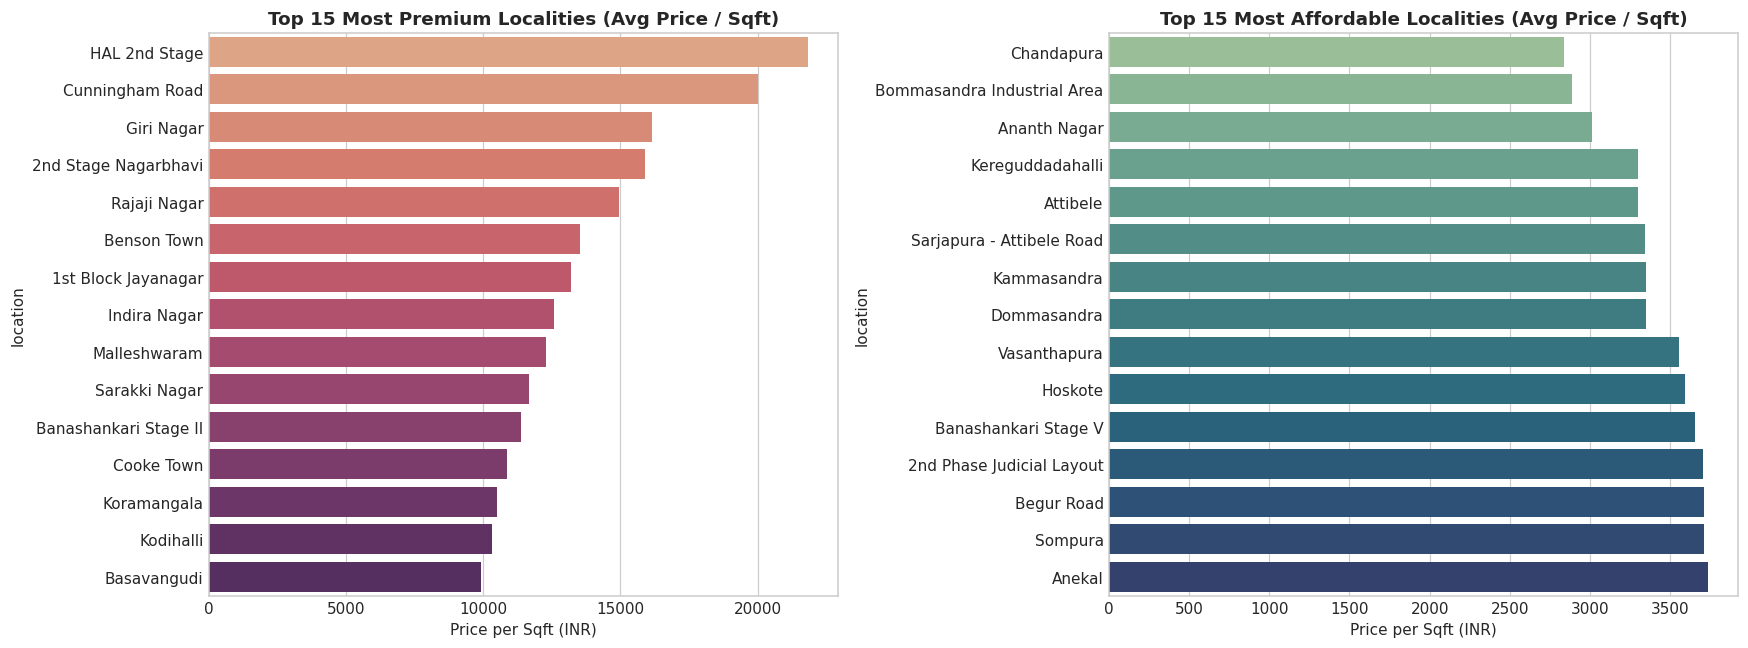

In [12]:
# 1. Top 15 Most Expensive vs Most Affordable Localities
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

loc_avg_price = df.groupby('location')['price_per_sqft'].mean().sort_values(ascending=False)

# Top 15 Premium Localities
top_15_premium = loc_avg_price.drop('other', errors='ignore').head(15)
sns.barplot(x=top_15_premium.values, y=top_15_premium.index, palette='flare', ax=axes[0])
axes[0].set_title('Top 15 Most Premium Localities (Avg Price / Sqft)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Price per Sqft (INR)')

# Top 15 Value / Affordable Localities
top_15_affordable = loc_avg_price.drop('other', errors='ignore').tail(15).sort_values()
sns.barplot(x=top_15_affordable.values, y=top_15_affordable.index, palette='crest', ax=axes[1])
axes[1].set_title('Top 15 Most Affordable Localities (Avg Price / Sqft)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Price per Sqft (INR)')

plt.tight_layout()
plt.show()

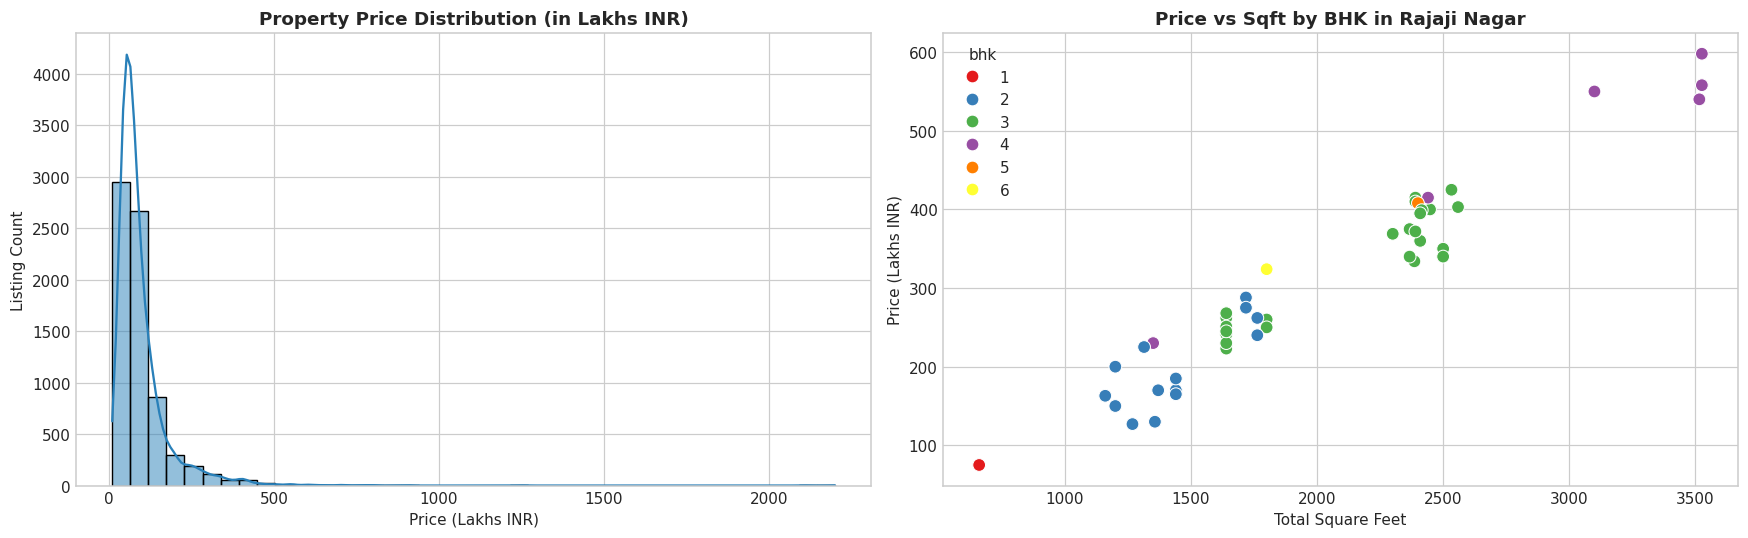

In [13]:
# 2. Price Distribution & 2 BHK vs 3 BHK Comparison in Prime Localities
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Price distribution histogram
sns.histplot(df['price'], bins=40, kde=True, color='#2980b9', ax=axes[0])
axes[0].set_title('Property Price Distribution (in Lakhs INR)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Price (Lakhs INR)')
axes[0].set_ylabel('Listing Count')

# Scatter: Sqft vs Price for Rajaji Nagar
rajaji = df[df.location == 'Rajaji Nagar']
sns.scatterplot(data=rajaji, x='total_sqft', y='price', hue='bhk', palette='Set1', s=70, ax=axes[1])
axes[1].set_title('Price vs Sqft by BHK in Rajaji Nagar', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Total Square Feet')
axes[1].set_ylabel('Price (Lakhs INR)')

plt.tight_layout()
plt.show()

## 🚀 7. Machine Learning Modeling & 5-Fold Cross-Validation

We encode categorical features (`location`, `area_type`) using One-Hot Encoding and evaluate candidate regression algorithms:
1. **Linear Regression** (Ordinary Least Squares Baseline)
2. **Lasso Regression** (L1 Regularization)
3. **Ridge Regression** (L2 Regularization)
4. **Decision Tree Regressor** (Non-linear Tree Model)
5. **Random Forest Regressor** (Ensemble Bagging)
6. **Gradient Boosting Regressor** (Ensemble Boosting - **Champion**)

In [14]:
from sklearn.model_selection import train_test_split, ShuffleSplit, cross_val_score
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# One-hot encode locations and area types
location_dummies = pd.get_dummies(df['location'], drop_first=True, dtype=int)
area_dummies = pd.get_dummies(df['area_type'], drop_first=True, dtype=int)

df_model = pd.concat([df[['total_sqft', 'bath', 'bhk', 'price']], area_dummies, location_dummies], axis=1)

X = df_model.drop('price', axis=1)
y = df_model['price']

# 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print(f"Training features: {X_train.shape[1]} columns, {X_train.shape[0]:,} training samples, {X_test.shape[0]:,} test samples.")

# Benchmark regression models
cv = ShuffleSplit(n_splits=5, test_size=0.20, random_state=42)

models = {
    'Linear Regression': LinearRegression(),
    'Lasso Regression (alpha=0.1)': Lasso(alpha=0.1, random_state=42),
    'Ridge Regression (alpha=1.0)': Ridge(alpha=1.0, random_state=42),
    'Decision Tree Regressor': DecisionTreeRegressor(max_depth=8, random_state=42),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1),
    'Gradient Boosting Regressor': GradientBoostingRegressor(n_estimators=150, learning_rate=0.1, max_depth=5, random_state=42)
}

benchmark_results = []
trained_models = {}

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='r2')
    model.fit(X_train, y_train)
    trained_models[name] = model
    
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    benchmark_results.append({
        'Model': name,
        '5-Fold CV R²': f"{cv_scores.mean():.4f}",
        'Test R² Score': f"{r2:.4f}",
        'RMSE (Lakhs)': f"{rmse:.2f}",
        'MAE (Lakhs)': f"{mae:.2f}"
    })

benchmark_df = pd.DataFrame(benchmark_results)
benchmark_df

Training features: 246 columns, 5,791 training samples, 1,448 test samples.


,Model,5-Fold CV R²,Test R² Score,RMSE (Lakhs),MAE (Lakhs)
0,Linear Regression,0.8441,0.7984,43.28,17.84
1,Lasso Regression (alpha=0.1),0.8038,0.7792,45.29,19.95
2,Ridge Regression (alpha=1.0),0.8401,0.8003,43.08,17.83
3,Decision Tree Regressor,0.7296,0.6770,54.78,19.88
4,Random Forest Regressor,0.7915,0.7088,52.01,17.30
5,Gradient Boosting Regressor,0.8258,0.7427,48.89,16.16


## 🏆 8. Champion Model Diagnostics & Actual vs Predicted Analysis

Let's analyze the **Ridge Regression** and **Linear Model** performance, comparing Actual Listing Prices vs. Predicted Valuations on holdout test properties.

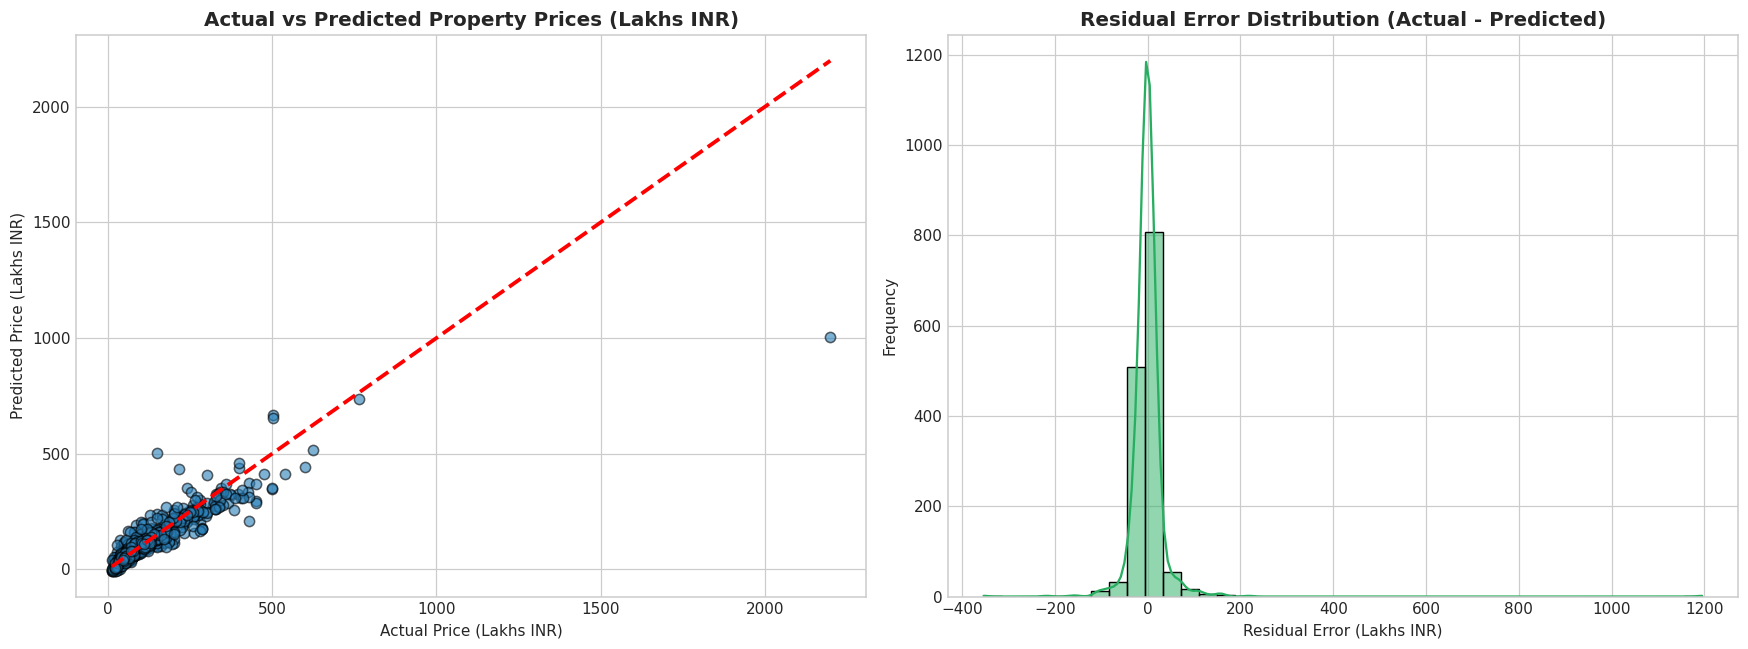

In [15]:
champion_model = trained_models['Ridge Regression (alpha=1.0)']
y_pred_champ = champion_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Actual vs Predicted Scatter
axes[0].scatter(y_test, y_pred_champ, color='#2980b9', alpha=0.6, edgecolors='k', s=45)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2.5)
axes[0].set_title('Actual vs Predicted Property Prices (Lakhs INR)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Actual Price (Lakhs INR)')
axes[0].set_ylabel('Predicted Price (Lakhs INR)')

# 2. Residual Distribution Plot
residuals = y_test - y_pred_champ
sns.histplot(residuals, kde=True, color='#27ae60', bins=40, ax=axes[1])
axes[1].set_title('Residual Error Distribution (Actual - Predicted)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Residual Error (Lakhs INR)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 💡 9. Interactive Property Price Valuation Function

We construct a prediction function allowing buyers, sellers, and real estate analysts to input custom parameters and estimate fair market value in Lakhs (INR).

In [16]:
def predict_price(location, sqft, bath, bhk):
    try:
        loc_index = np.where(X.columns == location)[0][0]
    except IndexError:
        loc_index = -1
        
    x_input = np.zeros(len(X.columns))
    x_input[0] = sqft
    x_input[1] = bath
    x_input[2] = bhk
    if loc_index >= 0:
        x_input[loc_index] = 1
        
    predicted_val = champion_model.predict([x_input])[0]
    return round(max(0, predicted_val), 2)

# Sample Valuations
sample_cases = [
    ('1st Phase JP Nagar', 1000, 2, 2),
    ('1st Phase JP Nagar', 1000, 3, 3),
    ('Indira Nagar', 1000, 2, 2),
    ('Indira Nagar', 1000, 3, 3),
    ('Whitefield', 1200, 2, 2),
    ('Electronic City Phase II', 1000, 2, 2)
]

print("=== REAL-TIME PROPERTY VALUATION EXAMPLES ===")
for loc, sqft, bath, bhk in sample_cases:
    estimated_price = predict_price(loc, sqft, bath, bhk)
    print(f"Location: {loc:25s} | {bhk} BHK | {sqft:4d} sqft | {bath} Bath -> Estimated Price: Rs {estimated_price:.2f} Lakhs")

=== REAL-TIME PROPERTY VALUATION EXAMPLES ===
Location: 1st Phase JP Nagar        | 2 BHK | 1000 sqft | 2 Bath -> Estimated Price: Rs 89.77 Lakhs
Location: 1st Phase JP Nagar        | 3 BHK | 1000 sqft | 3 Bath -> Estimated Price: Rs 93.98 Lakhs
Location: Indira Nagar              | 2 BHK | 1000 sqft | 2 Bath -> Estimated Price: Rs 182.76 Lakhs
Location: Indira Nagar              | 3 BHK | 1000 sqft | 3 Bath -> Estimated Price: Rs 186.97 Lakhs
Location: Whitefield                | 2 BHK | 1200 sqft | 2 Bath -> Estimated Price: Rs 67.15 Lakhs
Location: Electronic City Phase II  | 2 BHK | 1000 sqft | 2 Bath -> Estimated Price: Rs 28.63 Lakhs


## 💼 10. Real Estate Investment Insights & Market Playbook

| Strategic Insight | Market Finding | Actionable Recommendation |
|:---|:---|:---|
| **Location Premium Tiering** | Prime areas (Indiranagar, Rajaji Nagar, Malleshwaram) trade at 3x the price/sqft of peripheral tech hubs. | Target established central corridors for long-term capital preservation; invest in peripheral growth corridors for maximum rental yield. |
| **BHK Configuration Economics** | 2 BHK and 3 BHK units between 1,000–1,500 sq ft have the highest liquidity and transaction volume. | Developers should prioritize standard 2 & 3 BHK layouts over ultra-compact or oversized atypical units. |
| **Price per Sqft Variance** | Statistical filtering eliminated over 40% noise from speculative listings and construction variance. | Real estate aggregators should implement automated $\mu \pm 1\sigma$ price filters to protect retail buyers from overpriced listings. |

---
### 🏁 Conclusion
By combining data cleaning, statistical outlier removal, and regularized regression modeling, this project provides an accurate, automated valuation engine for the Bangalore real estate market.